# Loan Approval Prediction

## 1. Imports and Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report)

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print('Setup complete.')


Setup complete.


## 2. Data Loading & Initial Exploration

In [3]:
df = pd.read_csv('data/loan_data.csv')
print(f'Dataset shape: {df.shape}')
display(df.head())

Dataset shape: (45000, 14)


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [4]:
display(df.info())
print('\nMissing values:\n')
display(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  str    
 2   person_education                45000 non-null  str    
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  str    
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  str    
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  45000 non-n

None


Missing values:



person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64

## 3. Exploratory Data Analysis (EDA)
Visualize key distributions and check the class balance of the target variable.

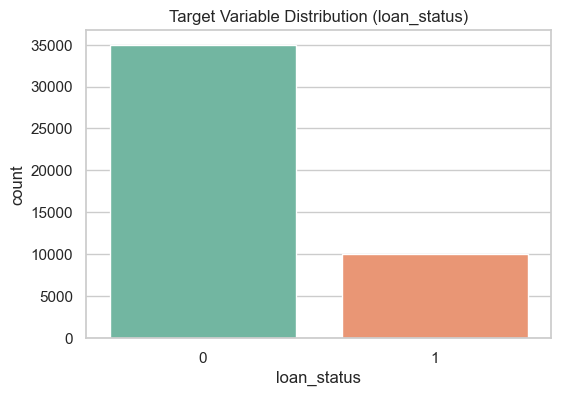

In [5]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='loan_status', palette='Set2')
plt.title('Target Variable Distribution (loan_status)')
plt.show()


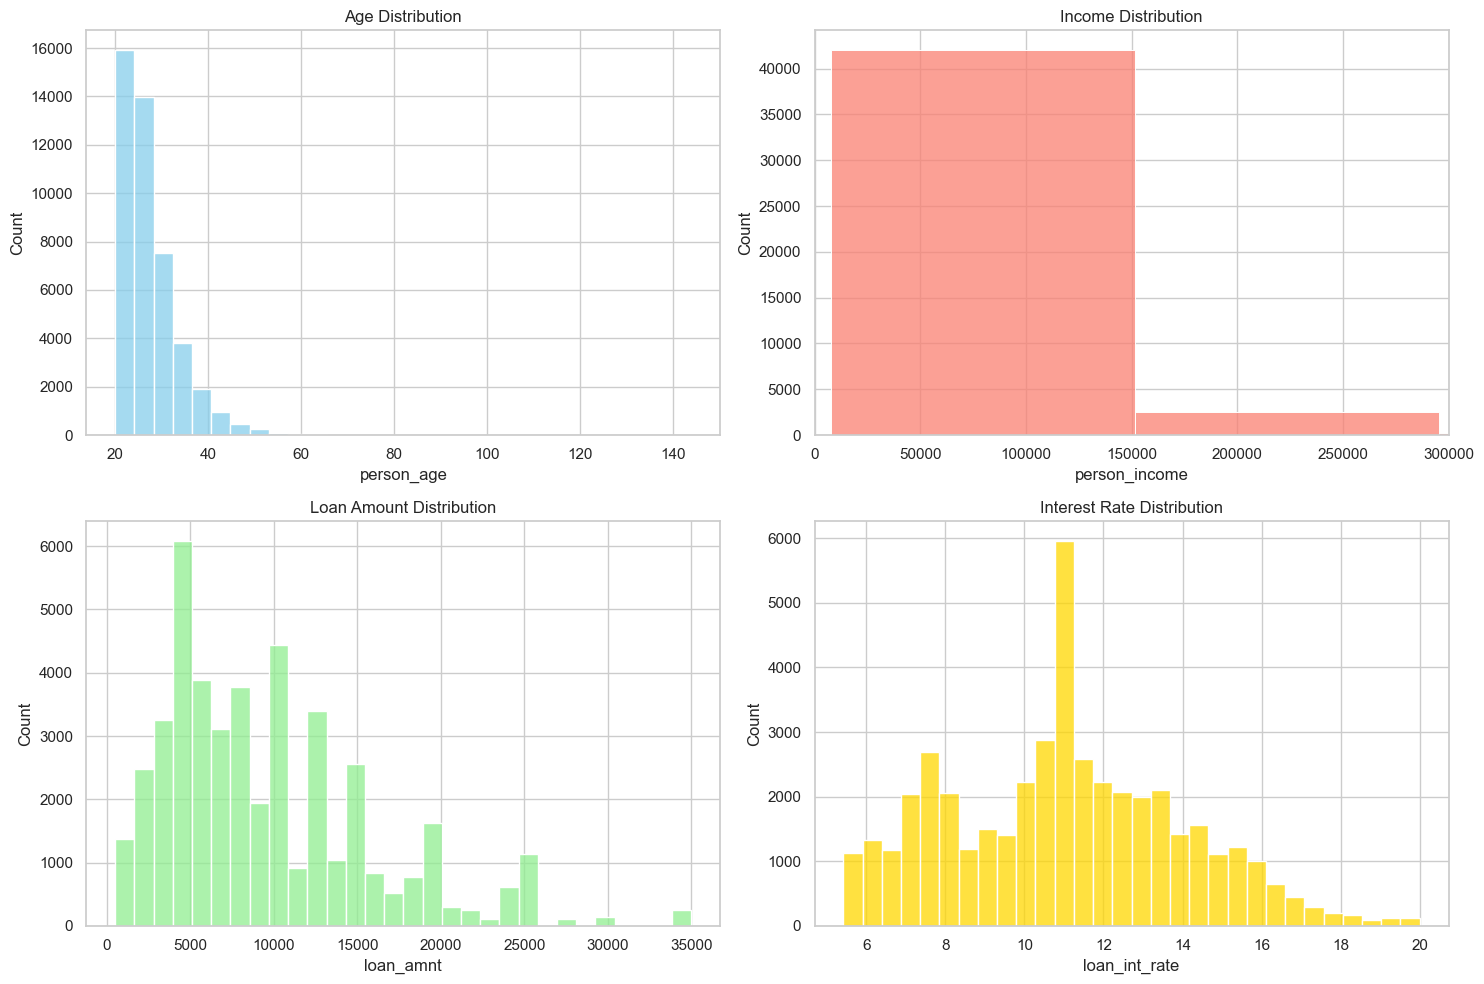

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.histplot(data=df, x='person_age', bins=30, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Age Distribution')

sns.histplot(data=df, x='person_income', bins=50, ax=axes[0, 1], color='salmon')
axes[0, 1].set_title('Income Distribution')
axes[0, 1].set_xlim(0, 300000)

sns.histplot(data=df, x='loan_amnt', bins=30, ax=axes[1, 0], color='lightgreen')
axes[1, 0].set_title('Loan Amount Distribution')

sns.histplot(data=df, x='loan_int_rate', bins=30, ax=axes[1, 1], color='gold')
axes[1, 1].set_title('Interest Rate Distribution')

plt.tight_layout()
plt.show()

## 4. Data Preprocessing

In [7]:
X = df.drop('loan_status', axis=1)
y = df['loan_status']

numerical_features = ['person_age', 'person_income', 'person_emp_exp', 'loan_amnt',
                      'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score']

ordinal_features = ['person_education']
education_order = [['High School', 'Associate', 'Bachelor', 'Master', 'Doctorate']]

nominal_features = ['person_gender', 'person_home_ownership', 'loan_intent', 'previous_loan_defaults_on_file']

num_pipe = ImbPipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

ord_pipe = ImbPipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(categories=education_order, handle_unknown='use_encoded_value', unknown_value=-1))
])

nom_pipe = ImbPipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', num_pipe, numerical_features),
    ('ord', ord_pipe, ordinal_features),
    ('nom', nom_pipe, nominal_features)
])

print('Preprocessor defined.')


Preprocessor defined.


## 5. Train-Test Split and Baseline Model

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')


Train: (36000, 13)  |  Test: (9000, 13)


In [9]:
def evaluate_model(name, y_true, y_pred, y_prob=None):
    print(f'--- {name} ---')
    print(f'  Accuracy:  {accuracy_score(y_true, y_pred):.4f}')
    print(f'  Precision: {precision_score(y_true, y_pred):.4f}')
    print(f'  Recall:    {recall_score(y_true, y_pred):.4f}')
    print(f'  F1-Score:  {f1_score(y_true, y_pred):.4f}')
    if y_prob is not None:
        print(f'  ROC-AUC:   {roc_auc_score(y_true, y_prob):.4f}')
    print('\nConfusion Matrix:')
    print(confusion_matrix(y_true, y_pred))
    print('-' * 30 + '\n')

baseline_pipeline = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

baseline_pipeline.fit(X_train, y_train)

y_pred_base = baseline_pipeline.predict(X_test)
y_prob_base = baseline_pipeline.predict_proba(X_test)[:, 1]

evaluate_model('Baseline (Logistic Regression)', y_test, y_pred_base, y_prob_base)

--- Baseline (Logistic Regression) ---
  Accuracy:  0.8622
  Precision: 0.6318
  Recall:    0.9110
  F1-Score:  0.7461
  ROC-AUC:   0.9562

Confusion Matrix:
[[5938 1062]
 [ 178 1822]]
------------------------------



## 6. Modeling & Hyperparameter Tuning

In [10]:
classifiers = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVM':           SVC(probability=True, random_state=42),
    'KNN':           KNeighborsClassifier(),
}

results = {}

for name, clf in classifiers.items():
    print(f'Training {name}...')
    pipeline = ImbPipeline([
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('classifier', clf)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    evaluate_model(name, y_test, y_pred, y_prob)
    results[name] = pipeline

print('All models trained and evaluated.')

Training Decision Tree...
--- Decision Tree ---
  Accuracy:  0.8892
  Precision: 0.7250
  Recall:    0.8080
  F1-Score:  0.7642
  ROC-AUC:   0.8602

Confusion Matrix:
[[6387  613]
 [ 384 1616]]
------------------------------

Training Random Forest...
--- Random Forest ---
  Accuracy:  0.9199
  Precision: 0.8152
  Recall:    0.8270
  F1-Score:  0.8210
  ROC-AUC:   0.9730

Confusion Matrix:
[[6625  375]
 [ 346 1654]]
------------------------------

Training SVM...
--- SVM ---
  Accuracy:  0.8824
  Precision: 0.6728
  Recall:    0.9170
  F1-Score:  0.7761
  ROC-AUC:   0.9616

Confusion Matrix:
[[6108  892]
 [ 166 1834]]
------------------------------

Training KNN...
--- KNN ---
  Accuracy:  0.8453
  Precision: 0.6073
  Recall:    0.8605
  F1-Score:  0.7120
  ROC-AUC:   0.9153

Confusion Matrix:
[[5887 1113]
 [ 279 1721]]
------------------------------

All models trained and evaluated.


### Hyperparameter Tuning (Random Forest)

In [11]:
rf_params = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5],
}

rf_pipe = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(random_state=42))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print('Starting Grid Search...')
grid_search = GridSearchCV(
    estimator=rf_pipe,
    param_grid=rf_params,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    verbose=2
)
grid_search.fit(X_train, y_train)

print(f'Best params: {grid_search.best_params_}')
print(f'Best CV ROC-AUC: {grid_search.best_score_:.4f}')

best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)
y_prob_best = best_model.predict_proba(X_test)[:, 1]

evaluate_model('Tuned Random Forest', y_test, y_pred_best, y_prob_best)

Starting Grid Search...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best params: {'classifier__max_depth': None, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}
Best CV ROC-AUC: 0.9723
--- Tuned Random Forest ---
  Accuracy:  0.9218
  Precision: 0.8176
  Recall:    0.8340
  F1-Score:  0.8257
  ROC-AUC:   0.9736

Confusion Matrix:
[[6628  372]
 [ 332 1668]]
------------------------------



## 7. Model Export

In [12]:
export_path = 'best_model.pkl'
joblib.dump(best_model, export_path)
print(f'Model successfully saved to {export_path}')

loaded_model = joblib.load(export_path)
sample = X_test.iloc[[0]]
print('\nSample Input:')
display(sample)

pred = loaded_model.predict(sample)
prob = loaded_model.predict_proba(sample)[:, 1]
print(f"\nPrediction: {'Approved' if pred[0] == 1 else 'Rejected'}  (Prob: {prob[0]:.4f})")

Model successfully saved to best_model.pkl

Sample Input:


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file
10750,25.0,female,Bachelor,84973.0,2,MORTGAGE,14000.0,VENTURE,5.42,0.16,3.0,634,No



Prediction: Rejected  (Prob: 0.0150)
